<a href="https://colab.research.google.com/github/WahyuKhairi06/imageprocessing_WahyuKhairi_2311531009/blob/main/Pertemuan%204/pertemuan_4_Histogram_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Import Library


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 2. Membaca Citra

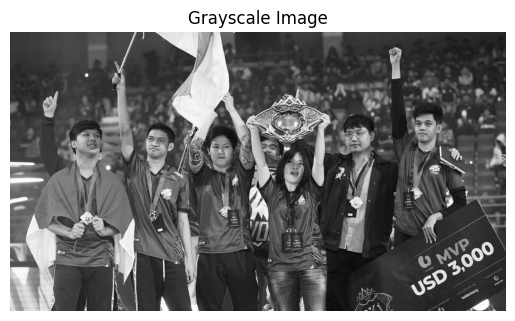

In [2]:
image = cv2.imread('m1.jpeg')

# Konversi ke grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Tampilkan citra grayscale
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 3. Menentukan Ukuran Citra

In [3]:
rows, cols = gray.shape

# 4. Menghitung Histogram Citra (Manual)

In [4]:
histogram = np.zeros(256)

for i in range(rows):
    for j in range(cols):
        intensity = gray[i,j]
        histogram[intensity] += 1


# 5. Menampilkan Histogram Sebelum Normalisasi

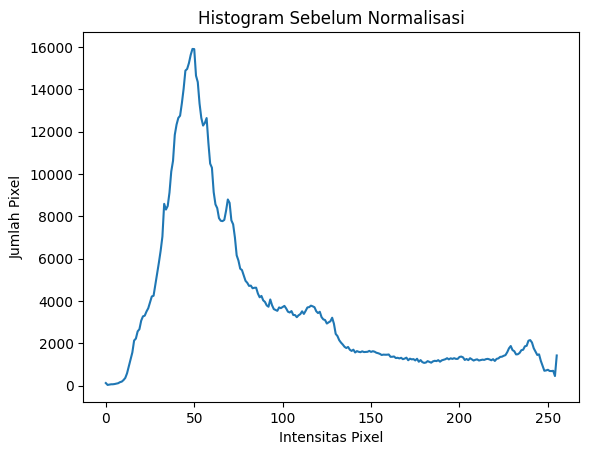

In [5]:
plt.plot(histogram)
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")
plt.show()


# 6. Normalisasi Histogram

In [6]:
total_pixel = rows * cols

hist_norm = histogram / total_pixel

# 7. Menampilkan Histogram Setelah Normalisasi

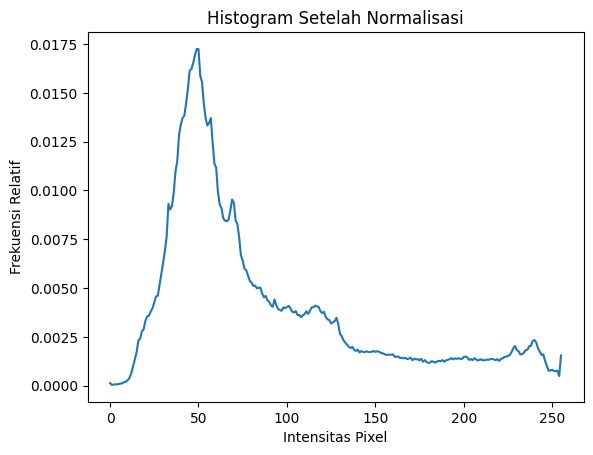

In [7]:
plt.plot(hist_norm)
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi Relatif")
plt.show()


# 8. Menghitung CDF (Cumulative Distribution Function)

In [8]:
cdf = np.zeros(256)

cdf[0] = hist_norm[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist_norm[i]

# 9. Membuat Mapping Intensitas Baru

In [9]:
mapping = np.zeros(256)

for i in range(256):
    mapping[i] = round(cdf[i] * 255)

mapping = mapping.astype('uint8')


# 10. Melakukan Histogram Equalization

In [10]:
equalized = np.zeros_like(gray)

for i in range(rows):
    for j in range(cols):
        equalized[i,j] = mapping[gray[i,j]]


# 11. Menampilkan Citra Hasil Equalization

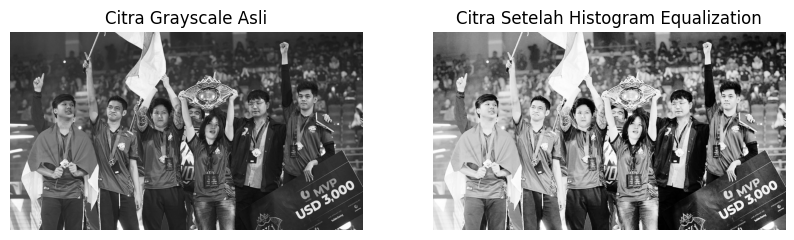

In [11]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Citra Grayscale Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")

plt.show()

# 12. Menghitung Histogram Setelah Equalization

In [12]:
hist_eq = np.zeros(256)

for i in range(rows):
    for j in range(cols):
        intensity = equalized[i,j]
        hist_eq[intensity] += 1


# 13. Menampilkan Histogram Setelah Equalization

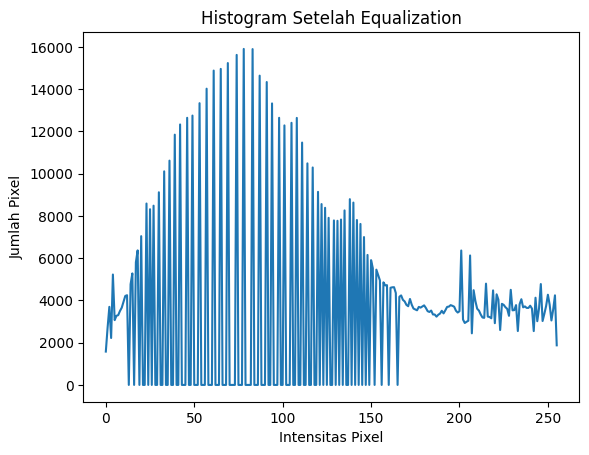

In [13]:
plt.plot(hist_eq)
plt.title("Histogram Setelah Equalization")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")
plt.show()